# Imports

In [239]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 500)

# Reading in the raw data (chestx)

In [240]:
df_raw = pd.read_csv("../data/raw/ChestX-ray14/Data_Entry_2017.csv")
df_raw = df_raw.drop(columns="Unnamed: 11")

In [241]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  object 
 1   Finding Labels               112120 non-null  object 
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Gender               112120 non-null  object 
 6   View Position                112120 non-null  object 
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
dtypes: float64(2), int64(5), object(4)
memory usage: 9.4+ MB


In [242]:
df_raw.describe()

,Follow-up #,Patient ID,Patient Age,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
count,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000
mean,8.573751,14346.381743,46.901463,2646.078844,2486.438842,0.155649,0.155649
std,15.406320,8403.876972,16.839923,341.246429,401.268227,0.016174,0.016174
min,0.000000,1.000000,1.000000,1143.000000,966.000000,0.115000,0.115000
25%,0.000000,7310.750000,35.000000,2500.000000,2048.000000,0.143000,0.143000
50%,3.000000,13993.000000,49.000000,2518.000000,2544.000000,0.143000,0.143000
75%,10.000000,20673.000000,59.000000,2992.000000,2991.000000,0.168000,0.168000
max,183.000000,30805.000000,414.000000,3827.000000,4715.000000,0.198800,0.198800


In [243]:
df_raw.head(1)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143


### Finding error of patients having age above 100 years (minimum age above 100 is 148)

In [244]:
df_raw[df_raw["Patient Age"] >= 100]

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
20852,00005567_000.png,Effusion|Pneumonia,0,5567,412,M,AP,3056,2544,0.139,0.139
46965,00011973_002.png,Edema,2,11973,414,M,AP,3056,2544,0.139,0.139
48284,00012238_010.png,No Finding,10,12238,148,M,PA,2992,2991,0.143,0.143
55742,00013950_000.png,No Finding,0,13950,148,M,PA,2964,2939,0.143,0.143
58650,00014520_026.png,Infiltration|Mass,26,14520,150,M,PA,2992,2991,0.143,0.143
62929,00015558_000.png,No Finding,0,15558,149,M,PA,2992,2991,0.143,0.143
74884,00018366_044.png,Pneumothorax,44,18366,152,F,PA,2302,2991,0.143,0.143
78795,00019346_000.png,Infiltration,0,19346,151,F,PA,2678,2774,0.143,0.143
84810,00020900_002.png,No Finding,2,20900,411,M,AP,3056,2544,0.139,0.139
85404,00021047_002.png,Mass|Pleural_Thickening,2,21047,412,M,AP,3056,2544,0.139,0.139


In [245]:
print(df_raw["Patient Age"].describe())
print(df_raw[df_raw["Patient Age"] == 0].shape[0])
print(df_raw[df_raw["Patient Age"] > 100].shape[0])
df_raw[df_raw["Patient Age"] > 100]

count    112120.000000
mean         46.901463
std          16.839923
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max         414.000000
Name: Patient Age, dtype: float64
0
16


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
20852,00005567_000.png,Effusion|Pneumonia,0,5567,412,M,AP,3056,2544,0.139,0.139
46965,00011973_002.png,Edema,2,11973,414,M,AP,3056,2544,0.139,0.139
48284,00012238_010.png,No Finding,10,12238,148,M,PA,2992,2991,0.143,0.143
55742,00013950_000.png,No Finding,0,13950,148,M,PA,2964,2939,0.143,0.143
58650,00014520_026.png,Infiltration|Mass,26,14520,150,M,PA,2992,2991,0.143,0.143
62929,00015558_000.png,No Finding,0,15558,149,M,PA,2992,2991,0.143,0.143
74884,00018366_044.png,Pneumothorax,44,18366,152,F,PA,2302,2991,0.143,0.143
78795,00019346_000.png,Infiltration,0,19346,151,F,PA,2678,2774,0.143,0.143
84810,00020900_002.png,No Finding,2,20900,411,M,AP,3056,2544,0.139,0.139
85404,00021047_002.png,Mass|Pleural_Thickening,2,21047,412,M,AP,3056,2544,0.139,0.139


In [246]:
df_raw["Patient ID"].nunique()

30805

In [247]:
labels_chestx = df_raw["Finding Labels"].value_counts()
labels_chestx[:20]

Finding Labels
No Finding                           60361
Infiltration                          9547
Atelectasis                           4215
Effusion                              3955
Nodule                                2705
Pneumothorax                          2194
Mass                                  2139
Effusion|Infiltration                 1603
Atelectasis|Infiltration              1350
Consolidation                         1310
Atelectasis|Effusion                  1165
Pleural_Thickening                    1126
Cardiomegaly                          1093
Emphysema                              892
Infiltration|Nodule                    829
Atelectasis|Effusion|Infiltration      737
Fibrosis                               727
Edema                                  628
Cardiomegaly|Effusion                  484
Consolidation|Infiltration             441
Name: count, dtype: int64

In [248]:
label_sex_chestx = (df_raw.explode("Finding Labels").pivot_table(index="Finding Labels", columns="Patient Gender", 
                                   aggfunc="size", fill_value=0).sort_values(by=["F", "M"], ascending=False))
label_sex_chestx[:5]

Patient Gender,F,M
Finding Labels,,
No Finding,26439,33922
Infiltration,4164,5383
Effusion,1797,2158
Atelectasis,1612,2603
Pneumothorax,1193,1001


# Plotting the data

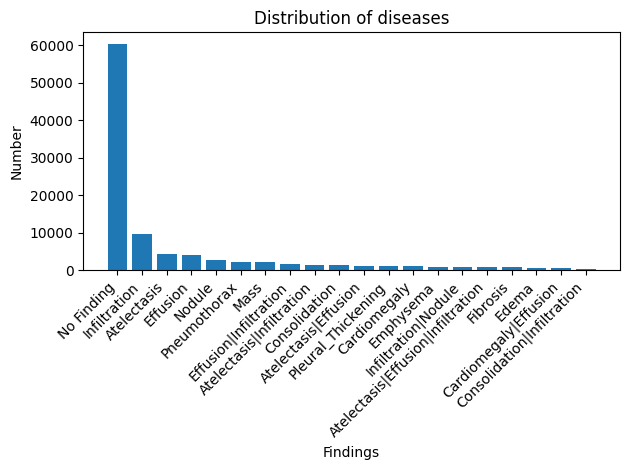

In [249]:
plt.figure()
labels_chestx = df_raw["Finding Labels"].value_counts()
plt.bar(labels_chestx[:20].index, labels_chestx[:20].values)
plt.title("Distribution of diseases")
plt.xlabel("Findings")
plt.ylabel("Number")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

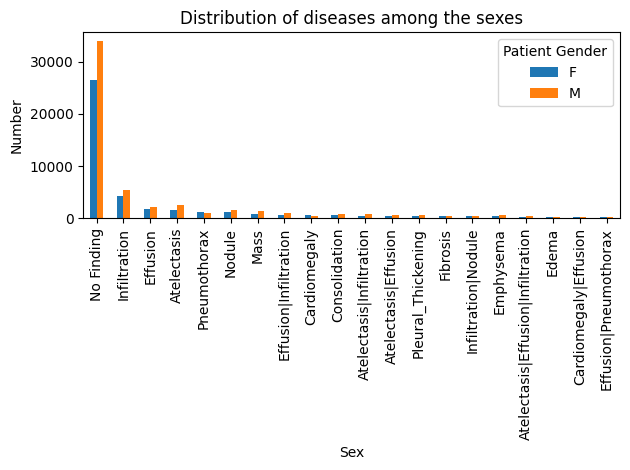

In [250]:
plt.figure()
label_sex_chestx[:20].plot(kind="bar")
plt.title("Distribution of diseases among the sexes")
plt.xlabel("Sex")
plt.ylabel("Number")
plt.tight_layout()
plt.show()

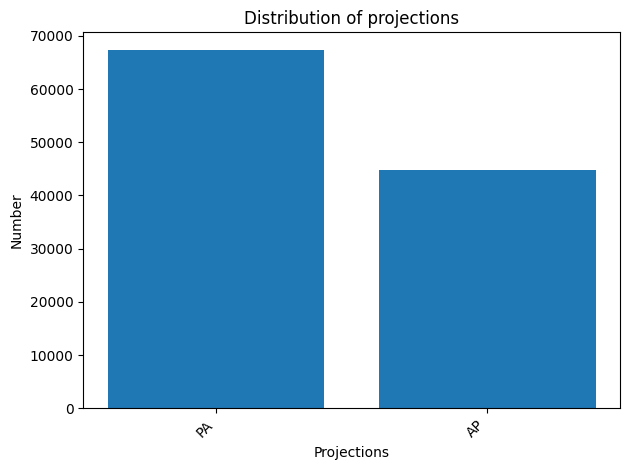

In [251]:
plt.figure()
view_counts = df_raw["View Position"].value_counts()
plt.bar(view_counts[:10].index, view_counts[:10].values)
plt.title("Distribution of projections")
plt.xlabel("Projections")
plt.ylabel("Number")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Reading in the processed data, and the drain data (chestx)

In [252]:
# df_drains_pos = pd.read_csv("../data/raw/ChestX-ray14/NIH-CX14_TubeAnnotations_NonExperts_aggregated.csv", index_col=0)
df_train_chestx = pd.read_csv("../data/processed/ChestX-ray14/train/files/processed_labels_train.csv", index_col=0)
df_test_chestx = pd.read_csv("../data/processed/ChestX-ray14/test/files/processed_labels_drains.csv", index_col=0)

In [253]:
df_train_chestx.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86524 entries, 0 to 112115
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Image Index                  86524 non-null  object 
 1   Finding Labels               86524 non-null  object 
 2   Follow-up #                  86524 non-null  int64  
 3   Patient ID                   86524 non-null  int64  
 4   Patient Age                  86524 non-null  int64  
 5   Patient Gender               86524 non-null  object 
 6   View Position                86524 non-null  object 
 7   OriginalImage[Width          86524 non-null  int64  
 8   Height]                      86524 non-null  int64  
 9   OriginalImagePixelSpacing[x  86524 non-null  float64
 10  y]                           86524 non-null  float64
 11  Unnamed: 11                  0 non-null      float64
 12  Pneumothorax                 86524 non-null  bool   
dtypes: bool(1), float64(

In [254]:
df_train_chestx.head(1)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,Pneumothorax
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN,False


In [255]:
df_test_chestx.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25596 entries, 0 to 25595
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Image Index                  25596 non-null  object 
 1   Finding Labels               25596 non-null  object 
 2   Follow-up #                  25596 non-null  int64  
 3   Patient ID                   25596 non-null  int64  
 4   Patient Age                  25596 non-null  int64  
 5   Patient Gender               25596 non-null  object 
 6   View Position                25596 non-null  object 
 7   OriginalImage[Width          25596 non-null  int64  
 8   Height]                      25596 non-null  int64  
 9   OriginalImagePixelSpacing[x  25596 non-null  float64
 10  y]                           25596 non-null  float64
 11  Unnamed: 11                  0 non-null      float64
 12  Unnamed: 0                   1760 non-null   float64
 13  Drain_a1             

In [256]:
df_test_chestx.head(1)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,Unnamed: 0,Drain_a1,Drain_Location_a1,Drain_a2,Drain_Location_a2,Drain,Pneumothorax
0,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,143.0,143.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,False


In [257]:
print("df_train_chestx", df_train_chestx["View Position"].value_counts())
print("df_test_chestx", df_test_chestx["View Position"].value_counts())

df_train_chestx View Position
PA    56214
AP    30310
Name: count, dtype: int64
df_test_chestx View Position
AP    14500
PA    11096
Name: count, dtype: int64


In [258]:
print(df_train_chestx["Image Index"].nunique())
print(df_test_chestx["Image Index"].nunique())

86524
25596


# Investigating `df_train_chestx`

## Sanity checking the dataset

In [259]:
print(df_train_chestx["Image Index"].nunique())
print(df_train_chestx["Patient ID"].nunique())

86524
28008


In [260]:
df_train_chestx.sort_values(by="Follow-up #", ascending=False)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,Pneumothorax
82758,00020326_108.png,No Finding,108,20326,27,F,AP,3056,2544,0.139,0.139,NaN,False
82757,00020326_107.png,No Finding,107,20326,27,F,AP,2500,2048,0.168,0.168,NaN,False
78197,00019176_107.png,Effusion|Infiltration,107,19176,67,F,AP,3056,2544,0.139,0.139,NaN,False
78196,00019176_106.png,Infiltration,106,19176,67,F,AP,3056,2544,0.139,0.139,NaN,False
82756,00020326_106.png,Infiltration,106,20326,27,F,AP,2500,2048,0.168,0.168,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
55109,00013802_000.png,Infiltration,0,13802,57,M,PA,2992,2991,0.143,0.143,NaN,False
55110,00013803_000.png,No Finding,0,13803,77,M,PA,2992,2991,0.143,0.143,NaN,False
55111,00013804_000.png,Infiltration,0,13804,34,M,PA,2992,2991,0.143,0.143,NaN,False
55112,00013805_000.png,Infiltration,0,13805,55,M,PA,2992,2991,0.143,0.143,NaN,False


In [261]:
df_train_chestx[(df_train_chestx["Patient ID"] == 20326) & (df_train_chestx["Pneumothorax"] == True)]

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,Pneumothorax
82713,00020326_063.png,Pneumothorax,63,20326,27,F,AP,2500,2048,0.168,0.168,NaN,True


In [262]:
print(df_train_chestx["Patient Age"].describe())
print(df_train_chestx[df_train_chestx["Patient Age"] == 0].shape[0])
print(df_train_chestx[df_train_chestx["Patient Age"] > 100].shape[0])

count    86524.000000
mean        46.870071
std         16.835434
min          1.000000
25%         35.000000
50%         49.000000
75%         59.000000
max        413.000000
Name: Patient Age, dtype: float64
0
12


# Investigating `df_test`

### We will use `df_test` as that is the one that contains all the necessary data
Such as the drain annotations for the positive AND negative cases of pneumothorax

In [263]:
df_test_chestx = df_test_chestx.drop(columns=["Unnamed: 11", "Unnamed: 0"])
df_test_chestx.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Drain_a1,Drain_Location_a1,Drain_a2,Drain_Location_a2,Drain,Pneumothorax
0,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,143.0,143.0,NaN,NaN,NaN,NaN,0.0,False
1,00000003_001.png,Hernia,1,3,74,F,PA,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,0.0,False
2,00000003_002.png,Hernia,2,3,75,F,PA,2048,2500,168.0,168.0,NaN,NaN,NaN,NaN,0.0,False
3,00000003_003.png,Hernia|Infiltration,3,3,76,F,PA,2698,2991,143.0,143.0,NaN,NaN,NaN,NaN,0.0,False
4,00000003_004.png,Hernia,4,3,77,F,PA,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,0.0,False


## Sanity checking the dataset

In [264]:
print(df_test_chestx["Image Index"].nunique())
print(df_test_chestx["Patient ID"].nunique())

25596
2797


In [265]:
df_test_chestx.sort_values(by="Follow-up #", ascending=False)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Drain_a1,Drain_Location_a1,Drain_a2,Drain_Location_a2,Drain,Pneumothorax
6428,00010007_183.png,Effusion|Infiltration,183,10007,59,M,AP,2500,2048,168.000000,168.000000,NaN,NaN,NaN,NaN,0.0,False
6427,00010007_182.png,Consolidation,182,10007,59,M,AP,2500,2048,168.000000,168.000000,NaN,NaN,NaN,NaN,1.0,False
6426,00010007_181.png,No Finding,181,10007,59,M,AP,2500,2048,168.000000,168.000000,NaN,NaN,NaN,NaN,0.0,False
6425,00010007_180.png,Infiltration|Pleural_Thickening,180,10007,59,M,AP,2500,2048,168.000000,168.000000,NaN,NaN,NaN,NaN,0.0,False
6424,00010007_179.png,Atelectasis|Effusion,179,10007,59,M,AP,2500,2048,168.000000,168.000000,NaN,NaN,NaN,NaN,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22180,00028309_000.png,No Finding,0,28309,21,M,PA,2544,3056,139.000000,139.000000,NaN,NaN,NaN,NaN,0.0,False
22181,00028310_000.png,No Finding,0,28310,62,M,PA,2992,2991,143.000000,143.000000,NaN,NaN,NaN,NaN,1.0,False
22182,00028311_000.png,No Finding,0,28311,32,F,PA,2544,3056,139.000000,139.000000,NaN,NaN,NaN,NaN,1.0,False
22183,00028312_000.png,No Finding,0,28312,59,F,PA,1843,1826,0.194311,0.194311,NaN,NaN,NaN,NaN,0.0,False


In [266]:
df_test_chestx[(df_test_chestx["Patient ID"] == 10007) & (df_test_chestx["Pneumothorax"] == True)]

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Drain_a1,Drain_Location_a1,Drain_a2,Drain_Location_a2,Drain,Pneumothorax
6293,00010007_048.png,Infiltration|Pleural_Thickening|Pneumothorax,48,10007,58,M,AP,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,0.0,True
6299,00010007_054.png,Effusion|Infiltration|Pneumothorax,54,10007,58,M,AP,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,0.0,True
6300,00010007_055.png,Effusion|Infiltration|Pneumothorax,55,10007,58,M,AP,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,1.0,True
6301,00010007_056.png,Effusion|Infiltration|Pneumothorax,56,10007,58,M,AP,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,1.0,True
6423,00010007_178.png,Effusion|Pneumothorax,178,10007,59,M,AP,2500,2048,168.0,168.0,NaN,NaN,NaN,NaN,0.0,True


In [267]:
print(df_test_chestx["Patient Age"].describe())
print(df_test_chestx[df_test_chestx["Patient Age"] == 0].shape[0])
print(df_test_chestx[df_test_chestx["Patient Age"] > 100].shape[0])

count    25596.000000
mean        47.007579
std         16.854982
min          1.000000
25%         34.000000
50%         49.000000
75%         59.000000
max        414.000000
Name: Patient Age, dtype: float64
0
4


In [268]:
df_test_chestx[df_test_chestx["Patient Age"] > 100]

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Drain_a1,Drain_Location_a1,Drain_a2,Drain_Location_a2,Drain,Pneumothorax
3488,00005567_000.png,Effusion|Pneumonia,0,5567,412,M,AP,3056,2544,139.0,139.0,NaN,NaN,NaN,NaN,1.0,False
8167,00011973_002.png,Edema,2,11973,414,M,AP,3056,2544,139.0,139.0,NaN,NaN,NaN,NaN,1.0,False
15610,00018366_044.png,Pneumothorax,44,18366,152,F,PA,2302,2991,143.0,143.0,1.0,L,1.0,L,1.0,True
17950,00021047_002.png,Mass|Pleural_Thickening,2,21047,412,M,AP,3056,2544,139.0,139.0,NaN,NaN,NaN,NaN,0.0,False


In [269]:
df_test_chestx[(df_test_chestx["Finding Labels"] == "No Finding") & (df_test_chestx["Drain"] == 1.0)].shape

(4263, 17)

# Exploding labels

In [270]:
test_chestx = df_test_chestx["Finding Labels"].str.split("|").explode()
test_label_chestx = test_chestx.value_counts()
print(test_label_chestx)

Finding Labels
No Finding            9861
Infiltration          6112
Effusion              4658
Atelectasis           3279
Pneumothorax          2665
Consolidation         1815
Mass                  1748
Nodule                1623
Pleural_Thickening    1143
Emphysema             1093
Cardiomegaly          1069
Edema                  925
Pneumonia              555
Fibrosis               435
Hernia                  86
Name: count, dtype: int64


In [271]:
train_chestx = df_train_chestx["Finding Labels"].str.split("|").explode()
train_label_chestx = train_chestx.value_counts()
print(train_label_chestx)

Finding Labels
No Finding            50500
Infiltration          13782
Effusion               8659
Atelectasis            8280
Nodule                 4708
Mass                   4034
Consolidation          2852
Pneumothorax           2637
Pleural_Thickening     2242
Cardiomegaly           1707
Emphysema              1423
Edema                  1378
Fibrosis               1251
Pneumonia               876
Hernia                  141
Name: count, dtype: int64


In [272]:
contradictions_test_chestx = df_test_chestx[df_test_chestx["Finding Labels"].str.contains("No Finding") & 
                               df_test_chestx["Finding Labels"].str.contains("\|")]
print(f"contradicting labels ('No Finding' + a disease): {len(contradictions_test_chestx)}")

contradicting labels ('No Finding' + a disease): 0


In [273]:
contradictions_train_chestx = df_train_chestx[df_train_chestx["Finding Labels"].str.contains("No Finding") & 
                               df_train_chestx["Finding Labels"].str.contains("\|")]
print(f"contradicting labels ('No Finding' + a disease): {len(contradictions_train_chestx)}")

contradicting labels ('No Finding' + a disease): 0


In [274]:
patient_grouping_train_chestx = df_train_chestx.groupby("Patient ID")["Patient Gender"].nunique()
patient_sexes_train_chestx = patient_grouping_train_chestx[patient_grouping_train_chestx > 1]
print(f"patients that have been registered to have more than one sex: {len(patient_sexes_train_chestx)}")

patients that have been registered to have more than one sex: 0


In [275]:
patient_grouping_test_chestx = df_test_chestx.groupby("Patient ID")["Patient Gender"].nunique()
patient_sexes_test_chestx = patient_grouping_test_chestx[patient_grouping_test_chestx > 1]
print(f"patients that have been registered to have more than one sex: {len(patient_sexes_test_chestx)}")

patients that have been registered to have more than one sex: 0


# Plotting the data

In [276]:
drains_pivot_test = (df_test_chestx.explode("Drain").pivot_table(index="Drain", columns="Patient Gender", 
                                   aggfunc="size", fill_value=0).sort_values(by=["F", "M"], ascending=False))
drains_pivot_test

Patient Gender,F,M
Drain,,
0.0,5577,7833
1.0,5137,7049


In [277]:
drains_pivot_train = (df_train_chestx.explode("Pneumothorax").pivot_table(index="Pneumothorax", columns="Patient Gender", 
                                   aggfunc="size", fill_value=0).sort_values(by=["F", "M"], ascending=False))
drains_pivot_train

Patient Gender,F,M
Pneumothorax,,
False,36712,47175
True,1354,1283


In [278]:
df_test_chestx["Drain"].value_counts()

Drain
0.0    13410
1.0    12186
Name: count, dtype: int64

<Figure size 640x480 with 0 Axes>

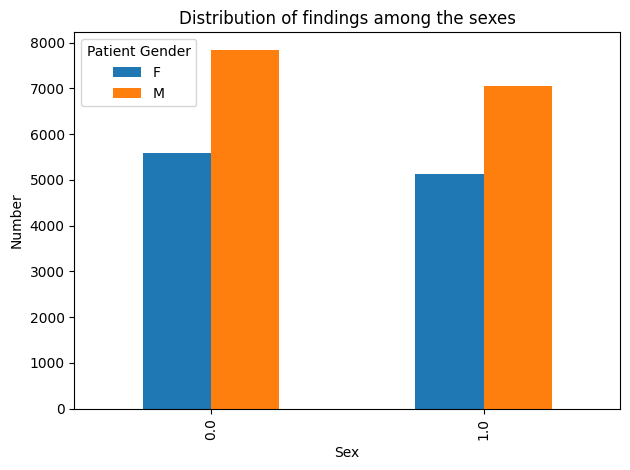

In [279]:
plt.figure()
drains_pivot_test.plot(kind="bar")
plt.title("Distribution of findings among the sexes")
plt.xlabel("Sex")
plt.ylabel("Number")
plt.tight_layout()
plt.show()

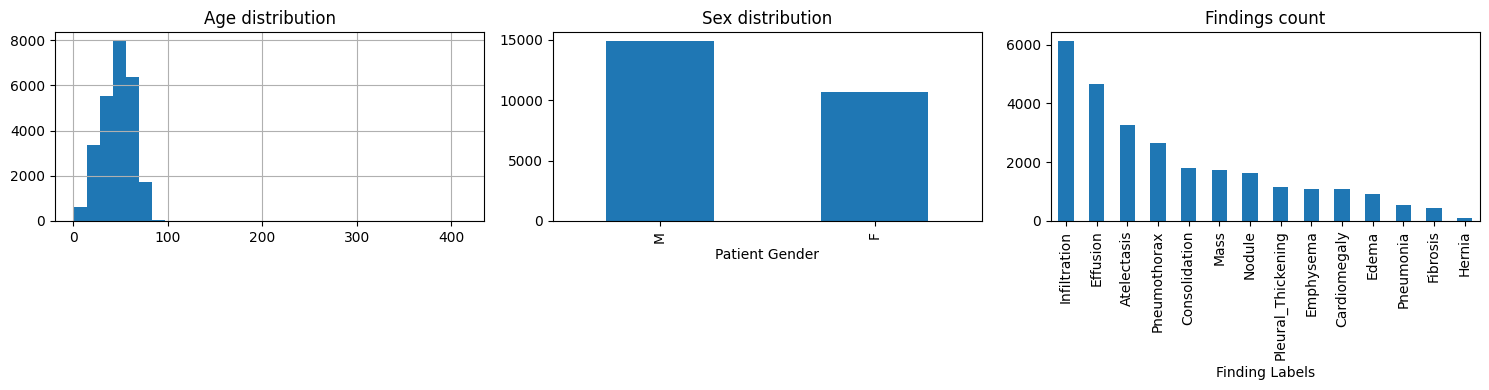

In [280]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_test_chestx["Patient Age"].hist(bins=30, ax=axes[0])
axes[0].set_title("Age distribution")

df_test_chestx["Patient Gender"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Sex distribution")

test_label_chestx.drop("No Finding", errors="ignore").plot(kind="bar", ax=axes[2])
axes[2].set_title("Findings count")

plt.tight_layout()
plt.show()

In [281]:
test_label_chestx

Finding Labels
No Finding            9861
Infiltration          6112
Effusion              4658
Atelectasis           3279
Pneumothorax          2665
Consolidation         1815
Mass                  1748
Nodule                1623
Pleural_Thickening    1143
Emphysema             1093
Cardiomegaly          1069
Edema                  925
Pneumonia              555
Fibrosis               435
Hernia                  86
Name: count, dtype: int64

In [282]:
findings_pivot_test_chestx = (df_test_chestx.explode("Finding Labels").pivot_table(index="Finding Labels", columns="Patient Gender", 
                                   aggfunc="size", fill_value=0).sort_values(by=["F", "M"], ascending=False))
findings_pivot_test_chestx[:100]

Patient Gender,F,M
Finding Labels,,
No Finding,4151,5710
Infiltration,887,1333
Effusion,477,690
Pneumothorax,455,498
Atelectasis,338,463
...,...,...
Consolidation|Fibrosis,7,7
Atelectasis|Edema,7,5
Mass|Pleural_Thickening|Pneumothorax,7,2


In [283]:
tester = (df_test_chestx.explode("Pneumothorax").pivot_table(index="Pneumothorax", 
                    columns=["Patient Gender"], aggfunc="size", fill_value=0))
tester["total"] = tester.sum(axis=1)
tester = tester.sort_values("total", ascending=False).drop(columns="total")
tester

Patient Gender,F,M
Pneumothorax,,
False,9483,13448
True,1231,1434


# PadChest

In [284]:
df_padchest_raw = pd.read_csv("../data/raw/PadChest/PADCHEST_chest_x_ray_images_labels_160K_01.02.19.csv")
df_padchest_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160861 entries, 0 to 160860
Data columns (total 36 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Unnamed: 0                       160861 non-null  int64  
 1   ImageID                          160861 non-null  object 
 2   ImageDir                         160861 non-null  int64  
 3   StudyDate_DICOM                  160861 non-null  int64  
 4   StudyID                          160861 non-null  object 
 5   PatientID                        160861 non-null  object 
 6   PatientBirth                     160855 non-null  float64
 7   PatientSex_DICOM                 160857 non-null  object 
 8   ViewPosition_DICOM               91776 non-null   object 
 9   Projection                       160861 non-null  object 
 10  MethodProjection                 160861 non-null  object 
 11  Pediatric                        160861 non-null  object 
 12  Mo

In [285]:
df_padchest_raw.head(1)

,Unnamed: 0,ImageID,ImageDir,StudyDate_DICOM,StudyID,PatientID,PatientBirth,PatientSex_DICOM,ViewPosition_DICOM,Projection,MethodProjection,Pediatric,Modality_DICOM,Manufacturer_DICOM,PhotometricInterpretation_DICOM,PixelRepresentation_DICOM,PixelAspectRatio_DICOM,SpatialResolution_DICOM,BitsStored_DICOM,WindowCenter_DICOM,WindowWidth_DICOM,Rows_DICOM,Columns_DICOM,XRayTubeCurrent_DICOM,Exposure_DICOM,ExposureInuAs_DICOM,ExposureTime,RelativeXRayExposure_DICOM,ReportID,Report,MethodLabel,Labels,Localizations,LabelsLocalizationsBySentence,labelCUIS,LocalizationsCUIS
0,0,20536686640136348236148679891455886468_k6ga29.png,0,20140915,20536686640136348236148679891455886468,839860488694292331637988235681460987,1930.0,F,POSTEROANTERIOR,PA,Manual review of DICOM fields,No,CR,ImagingDynamicsCompanyLtd,MONOCHROME2,0,NaN,NaN,12,2092.0,2251.0,1728,1872,250.0,2.0,2500.0,10.0,-1.42,4765777,sin hallazg patolog edad pacient .,Physician,['normal'],[],"[['normal'], ['normal']]",[],[]


In [286]:
df_padchest_raw["PatientID"].nunique()

67625

In [287]:
df_padchest = pd.read_csv("../data/processed/padchest/processed_labels.csv")
df_padchest_px = pd.read_csv("../data/processed/padchest/processed_labels_px.csv")

In [288]:
# same shapes, as preprocessing is the same (just different target labels), just sanity checking
print(df_padchest.shape)
print(df_padchest_px.shape)

(108094, 38)
(108094, 38)


In [289]:
idc = df_padchest_px[df_padchest_px["Manufacturer_DICOM"] == "ImagingDynamicsCompanyLtd"]
print(idc.shape)
idc["SpatialResolution_DICOM"].isna().sum()

(54348, 38)


54348

In [290]:
pms = df_padchest_px[df_padchest_px["Manufacturer_DICOM"] == "PhilipsMedicalSystems"]
print(pms.shape)
pms["SpatialResolution_DICOM"].isna().sum()

(53746, 38)


9691

In [291]:
df_padchest["Manufacturer_DICOM"].value_counts()

Manufacturer_DICOM
ImagingDynamicsCompanyLtd    54348
PhilipsMedicalSystems        53746
Name: count, dtype: int64

In [292]:
print(df_padchest["target_label"].value_counts())
print(df_padchest_px["target_label"].value_counts())

target_label
0    98433
1     9661
Name: count, dtype: int64
target_label
0    107711
1       383
Name: count, dtype: int64


In [293]:
label_sex = (df_padchest.explode("target_label").pivot_table(index="target_label", 
                    columns=["PatientSex_DICOM"], aggfunc="size", fill_value=0))
label_sex

PatientSex_DICOM,F,M,O
target_label,,,
0,48201,50216,13
1,5443,4217,1


In [294]:
label_sex_px = (df_padchest_px.explode("target_label").pivot_table(index="target_label", 
                    columns=["PatientSex_DICOM"], aggfunc="size", fill_value=0))
label_sex_px

PatientSex_DICOM,F,M,O
target_label,,,
0,53507,54187,14
1,137,246,0


In [295]:
label_manu = (df_padchest.explode("target_label").pivot_table(index="target_label", 
                    columns=["PatientSex_DICOM", "Manufacturer_DICOM"], aggfunc="size", fill_value=0))
label_manu["total"] = label_manu.sum(axis=1)
label_manu = label_manu.sort_values("total", ascending=False).drop(columns="total")

In [296]:
label_manu_px = (df_padchest_px.explode("target_label").pivot_table(index="target_label", 
                    columns=["PatientSex_DICOM", "Manufacturer_DICOM"], aggfunc="size", fill_value=0))
label_manu_px["total"] = label_manu_px.sum(axis=1)
label_manu_px = label_manu_px.sort_values("total", ascending=False).drop(columns="total")

In [297]:
label_manu

PatientSex_DICOM                           F                        \
Manufacturer_DICOM ImagingDynamicsCompanyLtd PhilipsMedicalSystems   
target_label                                                         
0                                      25234                 22967   
1                                       2776                  2667   

PatientSex_DICOM                           M                        \
Manufacturer_DICOM ImagingDynamicsCompanyLtd PhilipsMedicalSystems   
target_label                                                         
0                                      24391                 25825   
1                                       1940                  2277   

PatientSex_DICOM                           O                        
Manufacturer_DICOM ImagingDynamicsCompanyLtd PhilipsMedicalSystems  
target_label                                                        
0                                          5                     8  
1                                          1                     0

In [298]:
label_manu_px

PatientSex_DICOM                           F                        \
Manufacturer_DICOM ImagingDynamicsCompanyLtd PhilipsMedicalSystems   
target_label                                                         
0                                      27997                 25510   
1                                         13                   124   

PatientSex_DICOM                           M                        \
Manufacturer_DICOM ImagingDynamicsCompanyLtd PhilipsMedicalSystems   
target_label                                                         
0                                      26305                 27882   
1                                         26                   220   

PatientSex_DICOM                           O                        
Manufacturer_DICOM ImagingDynamicsCompanyLtd PhilipsMedicalSystems  
target_label                                                        
0                                          6                     8  
1                                          0                     0

# PadChest scanners (pneumothorax)
**female patients** with pneumothorax: 13 (IDC) and 124 (PMS) = 137

**female patients** without pneumothorax: 27997	(IDC) and 25510 (PMS) = 53507

**male patients** with pneumothorax: 26 (IDC) and 220 (PMS) = 246

**male patients** without pneumothorax: 26305 (IDC) and 27882 (PMS) = 54187

# PadChest scanners (cardiomegaly)
**ImagingDynamicsCompanyLtd** (IDC) overall: 25234 + 2776 + 24391 + 1940 = 54341

**PhilipsMedicalSystems** (PMS) overall: 22967 + 2667 + 25825 + 2277 = 53736

**ImagingDynamicsCompanyLtd** (IDC) for female patients: 25234 + 2776 = 28010

**PhilipsMedicalSystems** (PMS) for female patients: 22967 + 2667 = 25634

**ImagingDynamicsCompanyLtd** (IDC) for male patients: 24391 + 1940 = 26331

**PhilipsMedicalSystems** (PMS) for male patients: 25825 + 2277 = 28102

_________________________________
**female patients** with cardiomegaly: 2776 (IDC) and 2667 (PMS) = 5443

**female patients** without cardiomegaly: 25234	(IDC) and 22967 (PMS) = 48201

**male patients** with cardiomegaly: 1940 (IDC) and 2277 (PMS) = 4217

**male patients** without cardiomegaly: 24391 (IDC) and 25825 (PMS) = 50216